In [26]:
from pathlib import Path

import numpy  as np
import pandas as pd
import tables as tb
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from nbtools import auto_plot_style

from jupyfun import in_range

In [27]:
%matplotlib inline

auto_plot_style()

In [28]:
path            = Path("/home/gonzalo/data/COLINA/preamp_sipm_test_cold/")
path_mp1_lg     = path / "mp1-lg"
path_mp1_hg     = path / "mp1-hg"
path_mp2_lg     = path / "mp2-lg"
path_mp2_hg     = path / "mp2-hg"

In [29]:
def isfile(f):
    return f.suffix == ".h5"
    
def read(filename):
    with tb.open_file(filename) as f:
        time   = f.root.time.read()
        direct = f.root.C2.read()
        try:
            c3 = f.root.C3.read()
            c4 = f.root.C4.read()
            return time, direct, c4-c3, int(filename.stem)
        except Exception as e:
            return time, direct, int(filename.stem)

def integrate_signal(t, a, bline_window, signal_window):
    if a.ndim==1: a = a[np.newaxis]
    baseline = 0#np.mean(a[:, in_range(t,  *bline_window)]           , axis=1, keepdims=True)
    signal   = np.sum (a[:, in_range(t, *signal_window)] - baseline, axis=1)
    if a.ndim==1: signal = signal[0]
    return signal * (signal_window[1] - signal_window[0])

def signal_to_noise(t, a, bline_window, signal_window):
    noise    = np.std (a[in_range(t,  *bline_window )])
    baseline = np.mean(a[in_range(t,  *bline_window )])
    signal   = np.mean(a[in_range(t, *signal_window)] - baseline)
    return signal/noise

def mean_std(s):
    return pd.Series(dict(average=s.ratio.mean(), uaverage=s.ratio.std() / len(s)))

In [ ]:
filenames = sorted(path_mp2_hg.glob("*.h5"))
for filename in filenames[0:]:
    t, wfs, diff, led = read(filename)
    print(filename, led)
    for i in range(100, 200):
        wf = wfs[i]
        m1 = np.median(wf)
        m2 = np.mean(wf[in_range(t, -1, 0)])
        plt.figure(figsize=(12, 10))
        plt.subplot(2, 1, 1)
        plt.plot(t, wf)
        plt.grid()
        plt.title(str(i))
        plt.subplot(2, 1, 2)
        plt.plot(t, wf)
        plt.xlim(0, 0.3e-6)
        plt.grid()
        plt.tight_layout()
    break
        

In [ ]:
filenames = sorted(path_mp2_hg.glob("*.h5"))
for filename in filenames[0:]:
    t, wfs, diff, led = read(filename)
    print(filename, led)
    for i in range(28, 29):
        wf = wfs[i]
        m1 = np.median(wf)
        m2 = np.mean(wf[in_range(t, -1, 0)])
        plt.figure()
        plt.subplot(2, 1, 1)
        plt.plot(t, wf)
        plt.grid()
        plt.title(str(i))
        plt.subplot(2, 1, 2)
        plt.plot(t, wf)
        plt.xlim(1.4e-6, 1.8e-6)
        plt.grid()
        plt.tight_layout()
    break
        

In [53]:
import scipy.signal as signal

In [ ]:
filenames = sorted(path_mp2_hg.glob("*.h5"))
for filename in filenames[:1]:
    t, wfs, diff, led = read(filename)
    
    filt = signal.butter(8, 10e6*2/2e9, btype="low", analog=False)
    for i, wf in enumerate(diff):
        if i>20: break
        wff = signal.filtfilt(*filt, wf)
    
        plt.figure()
        plt.plot(t, wf)
        plt.plot(t, wff)
        plt.grid()
    

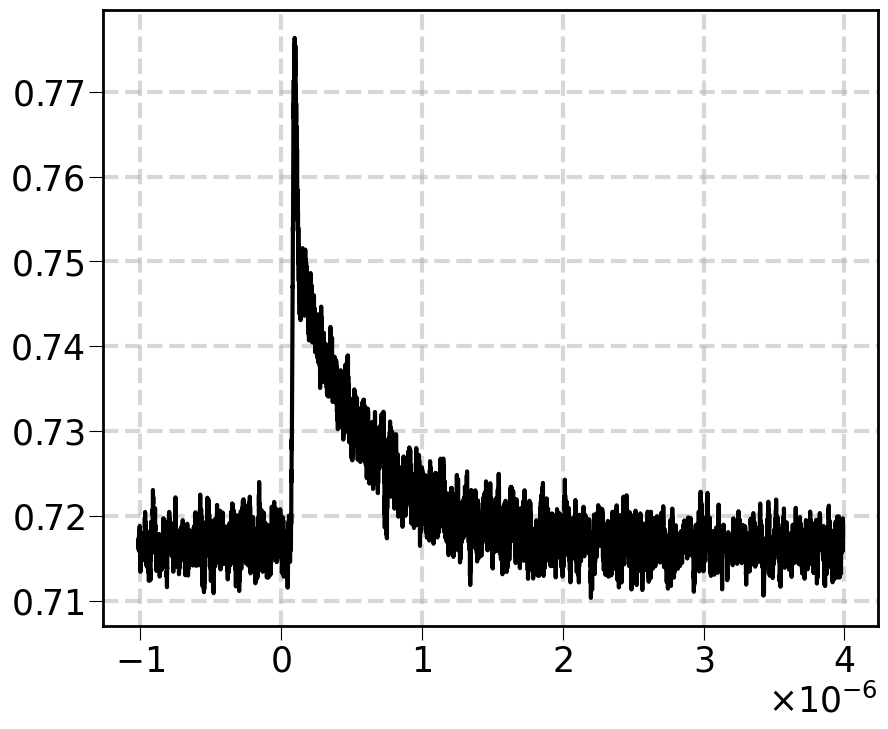

In [90]:
filenames = sorted(path_mp2_hg.glob("*.h5"))
for filename in filenames:
    t, wfs, diff, led = read(filename)
    wf = diff.mean(axis=0)
    plt.plot(t, wf)
    plt.grid()
    break

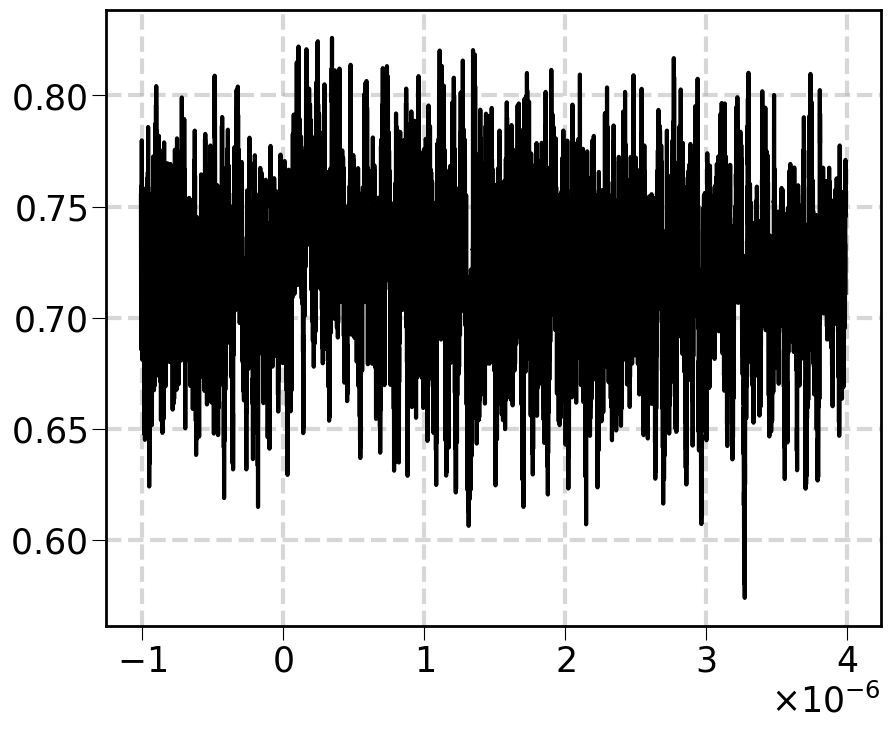

In [91]:
filenames = sorted(path_mp2_hg.glob("*.h5"))
for filename in filenames:
    t, wfs, diff, led = read(filename)
    for wf in diff:
        plt.plot(t, wf)
        plt.grid()
        break
    break

In [6]:
signal_window =     0, 2e-6
bline_window  = -2e-6, 0

# MP1 - LG

In [7]:
filenames = sorted(path_mp1_lg.glob("*.h5"))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp1lg = data

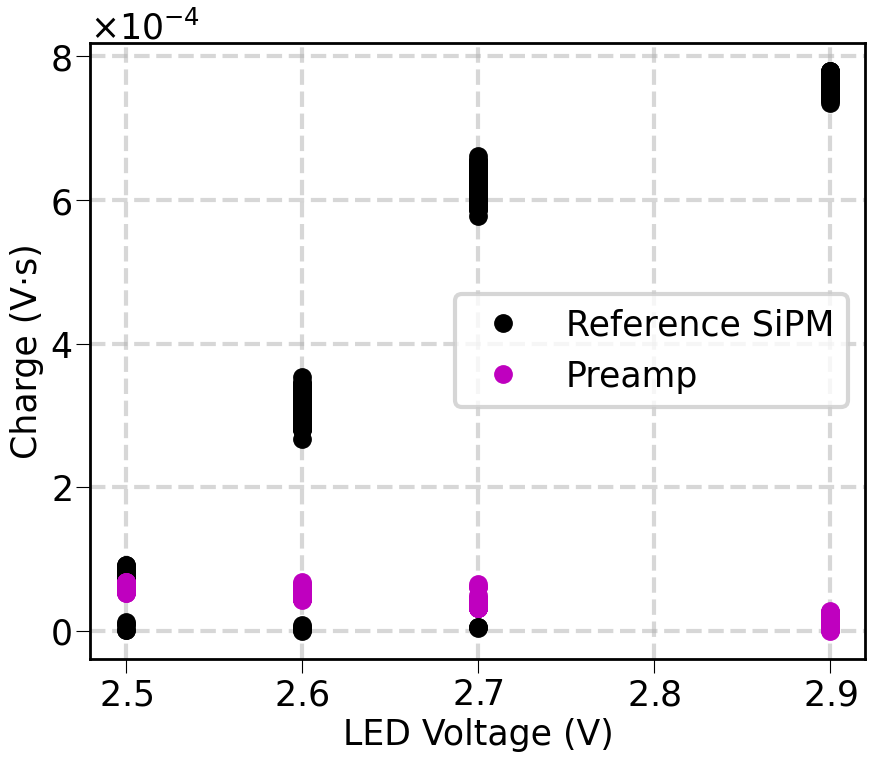

In [8]:
data = mp1lg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_81434/333666836.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("vled").apply(mean_std).reset_index()


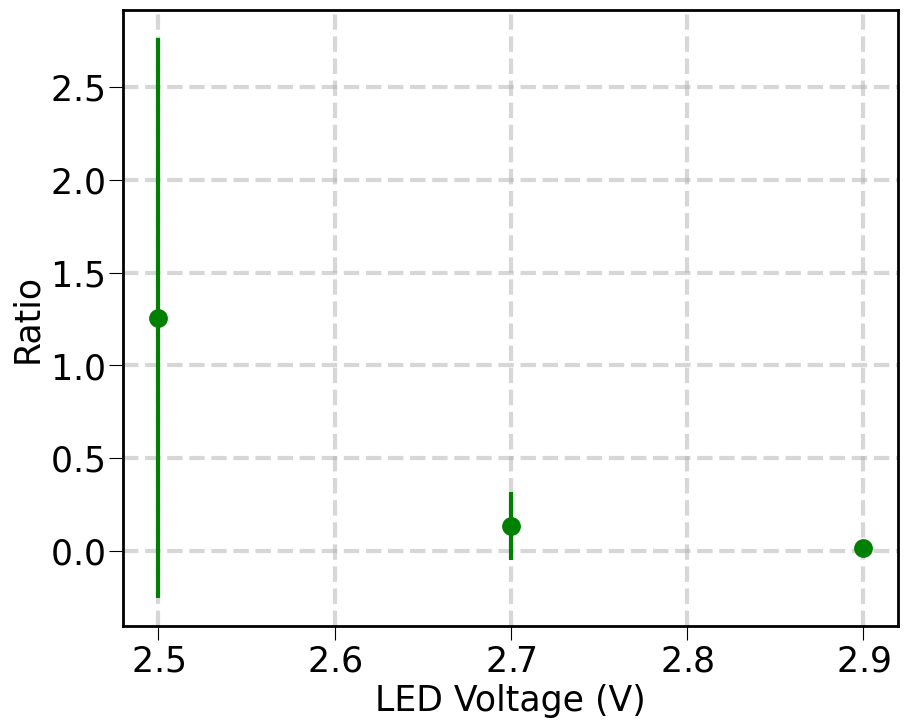

In [9]:
data = mp1lg
data = data.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, data.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

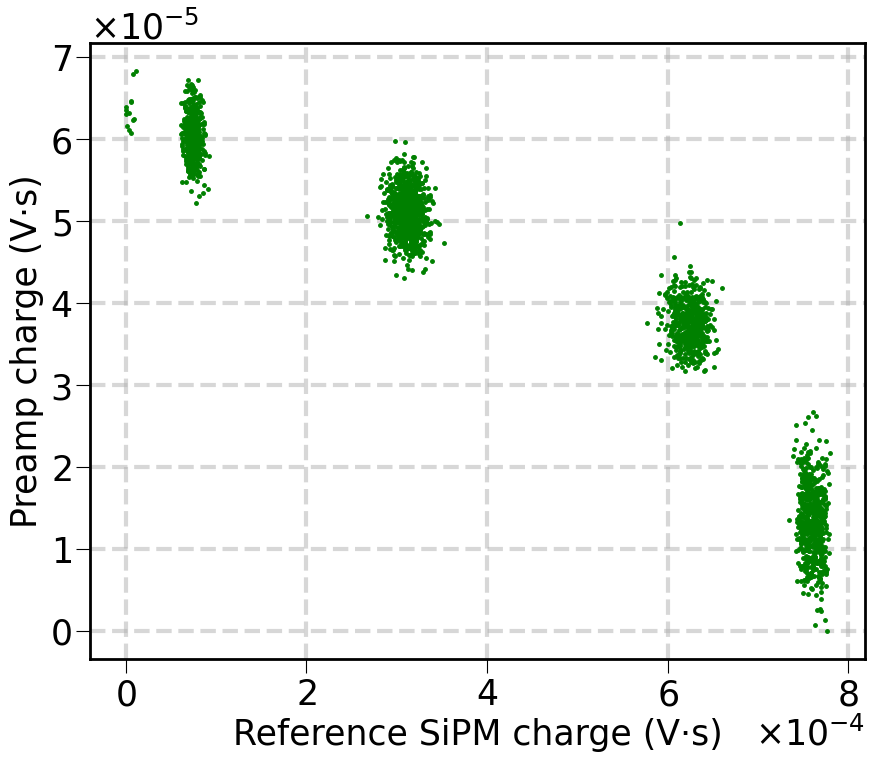

In [10]:
data = mp1lg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.grid()

# MP1 - HG

In [11]:
filenames = sorted(path_mp1_hg.glob("*.h5"))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp1hg = data

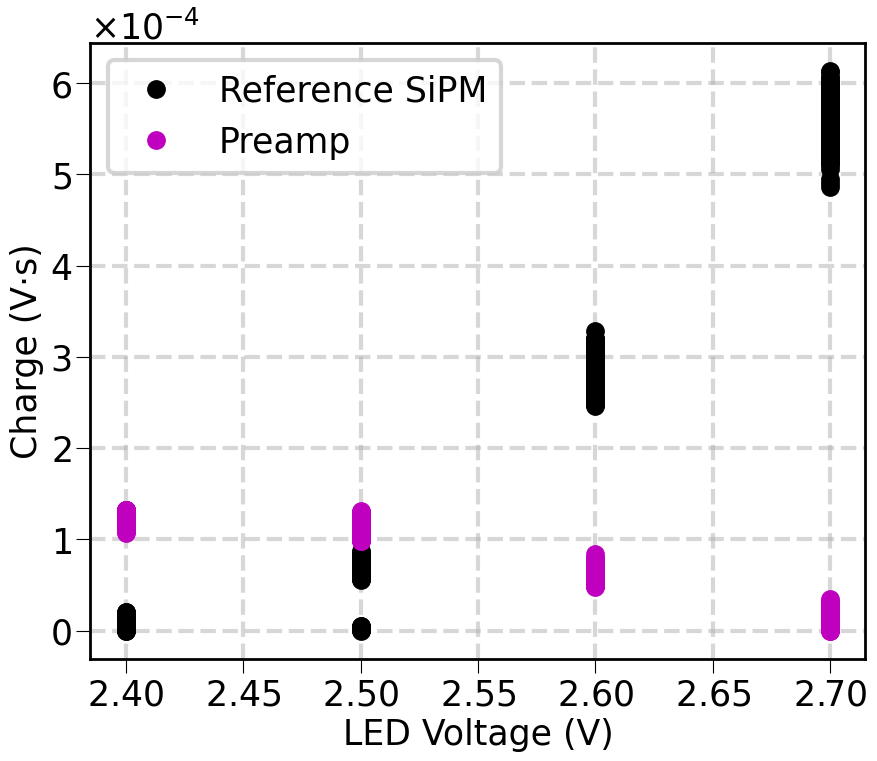

In [12]:
data = mp1hg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_81434/1710982714.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("vled").apply(mean_std).reset_index()


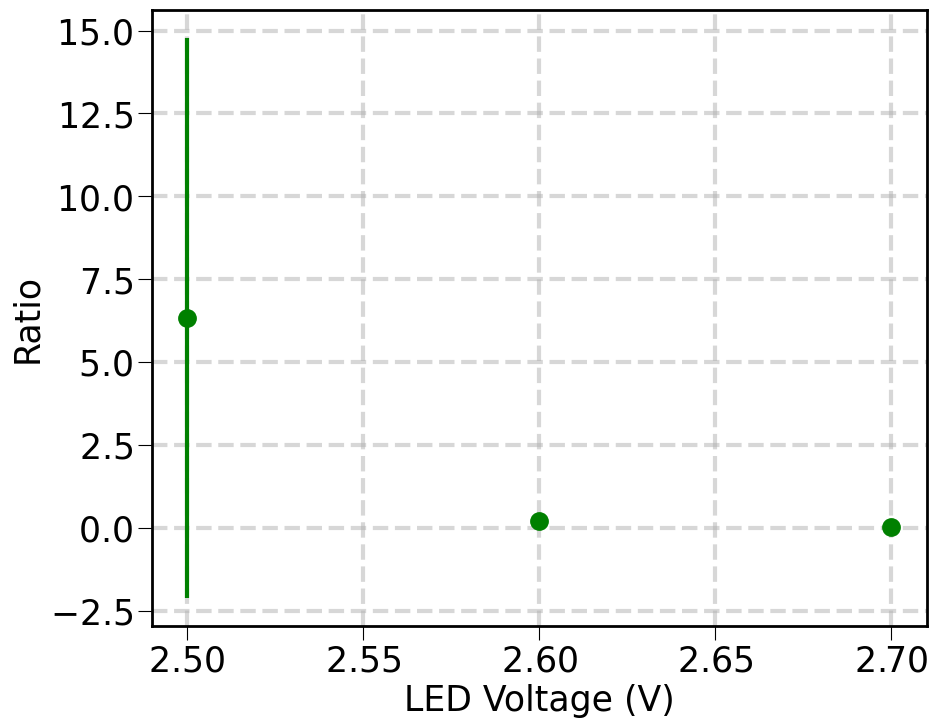

In [14]:
data = mp1hg
data = data.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, data.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

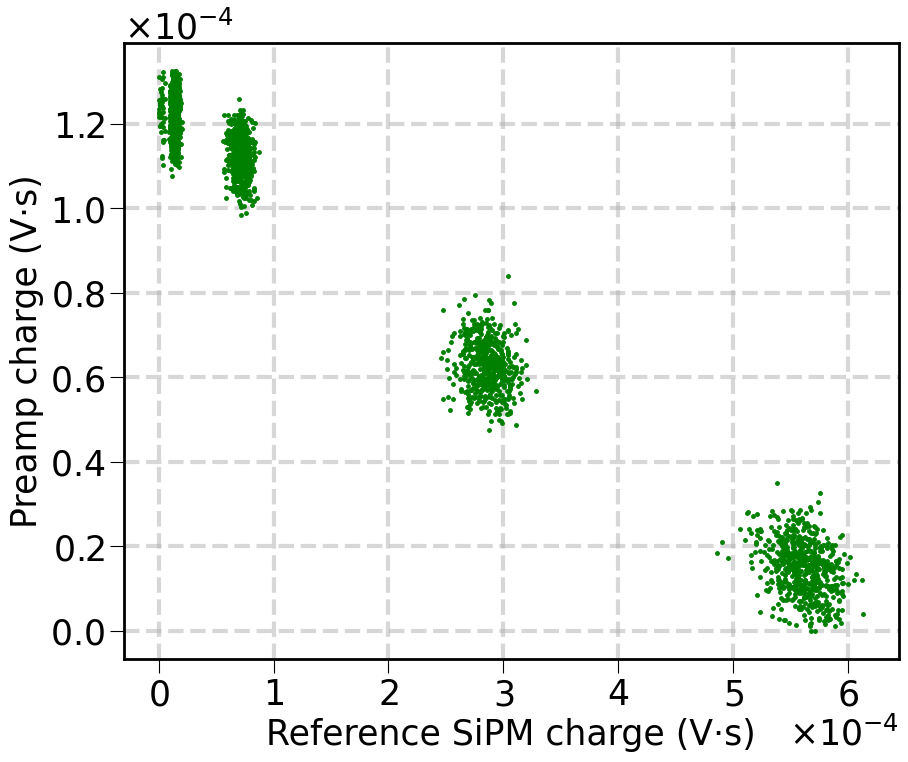

In [15]:
data = mp1hg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.grid()

# MP2 - LG

In [16]:
filenames = sorted(path_mp2_lg.glob("*.h5"))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp2lg = data

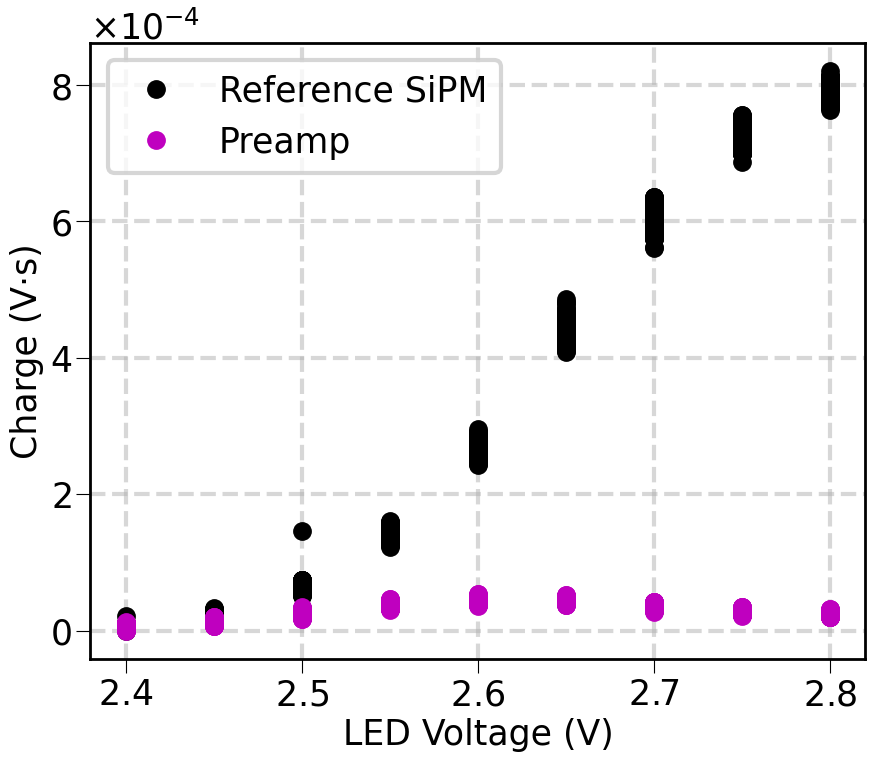

In [17]:
data = mp2lg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_81434/994726003.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("vled").apply(mean_std).reset_index()


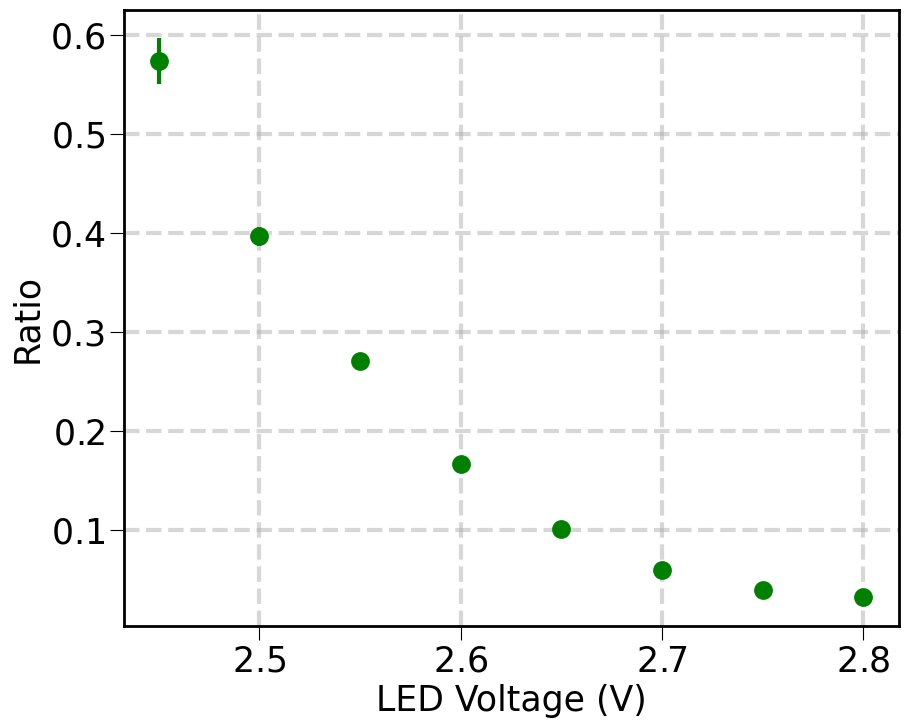

In [19]:
data = mp2lg
data = data.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, data.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

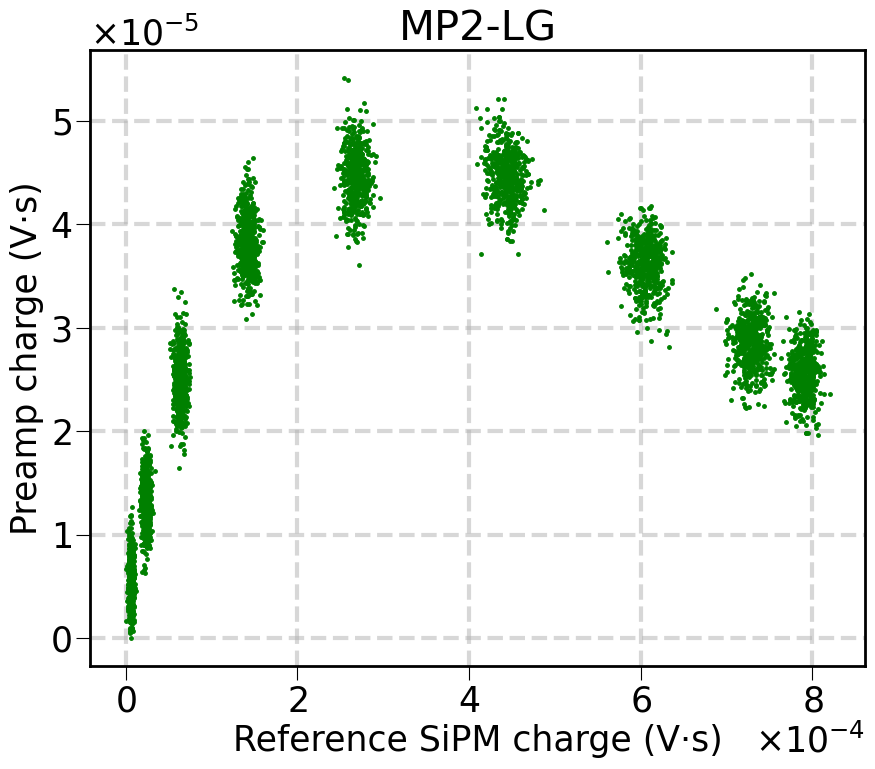

In [38]:
data = mp2lg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.title("MP2-LG")
plt.grid()

# MP2 - HG

In [21]:
filenames = sorted(path_mp2_hg.glob("*.h5"))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp2hg = data

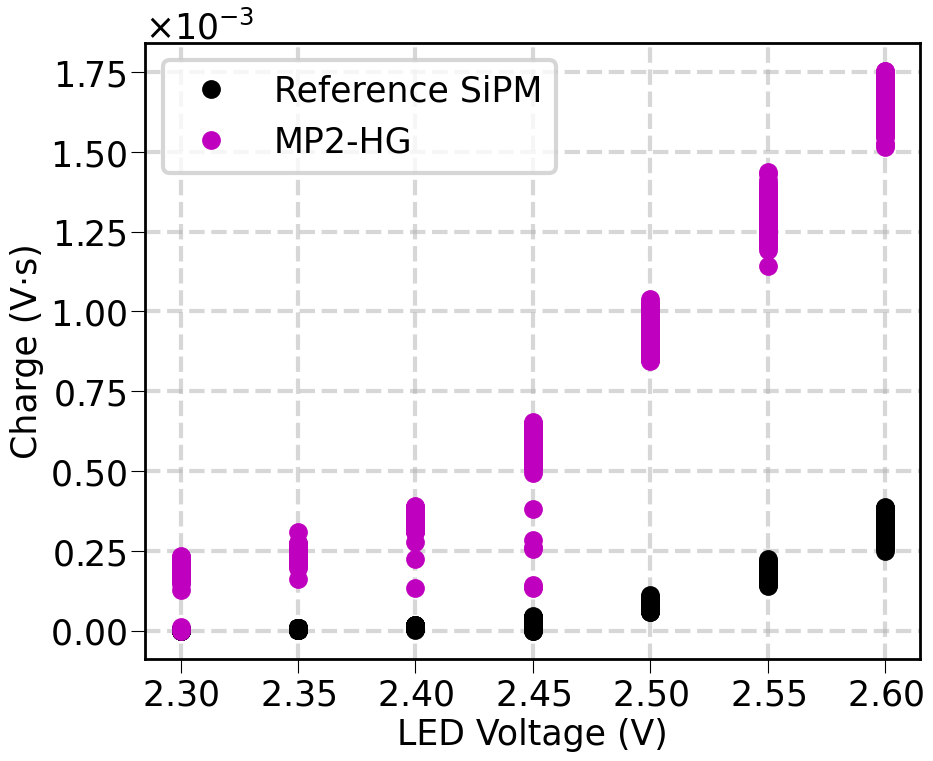

In [40]:
data = mp2hg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="MP2-HG")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_81434/4037466308.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("vled").apply(mean_std).reset_index()


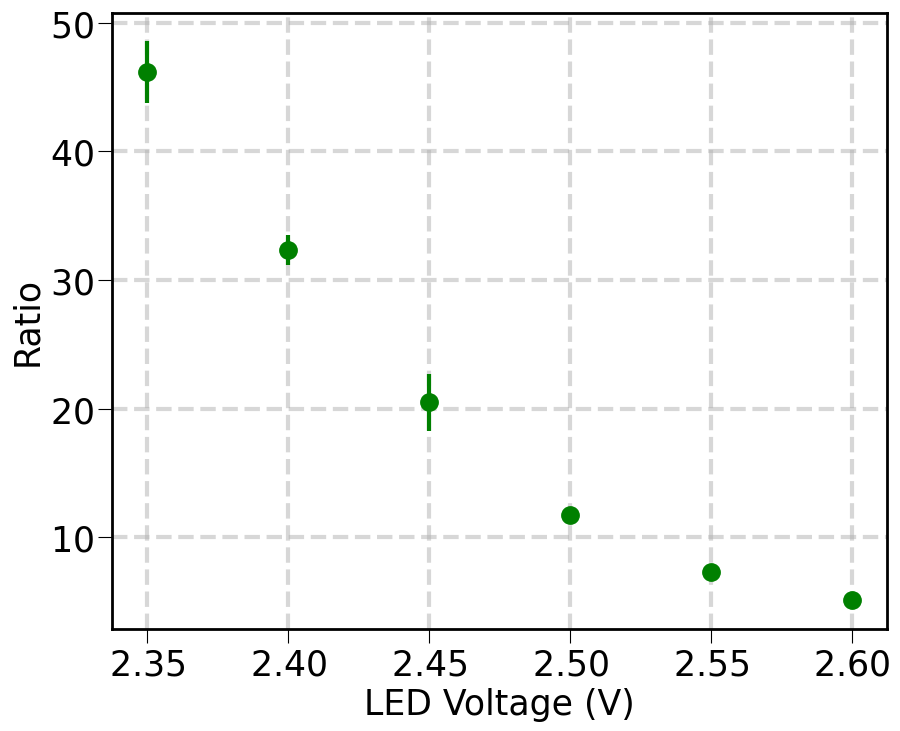

In [24]:
data = mp2hg
data = data.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, data.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

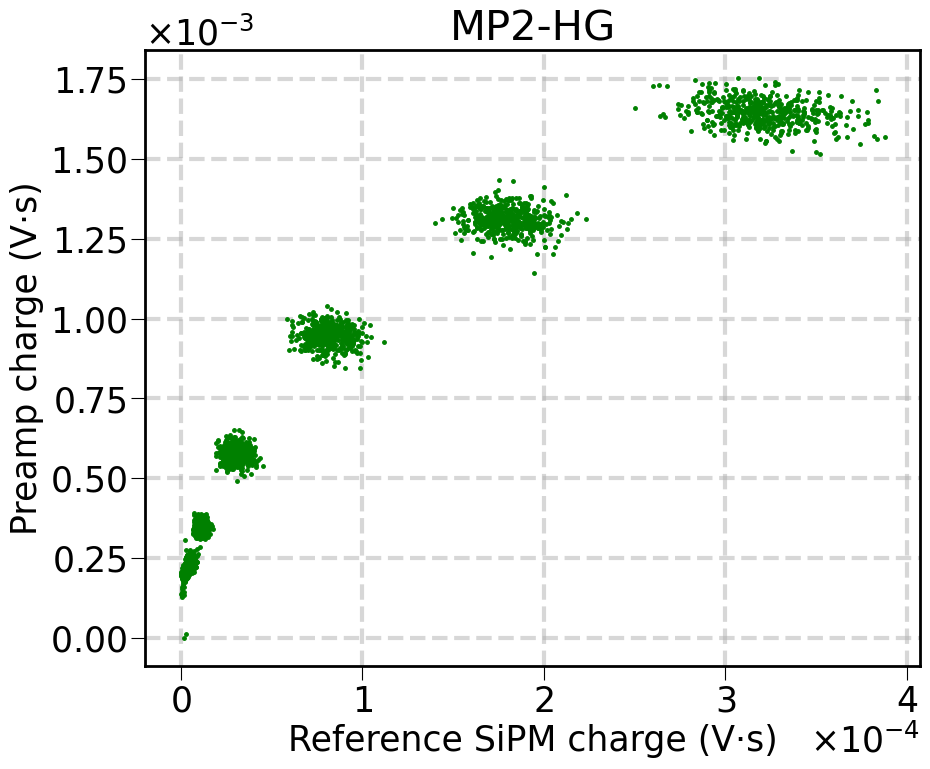

In [39]:
data = mp2hg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.title("MP2-HG")
plt.grid()

# SPE

In [86]:
mp2hg.vled.unique()

array([2300, 2350, 2400, 2450, 2500, 2550, 2600])

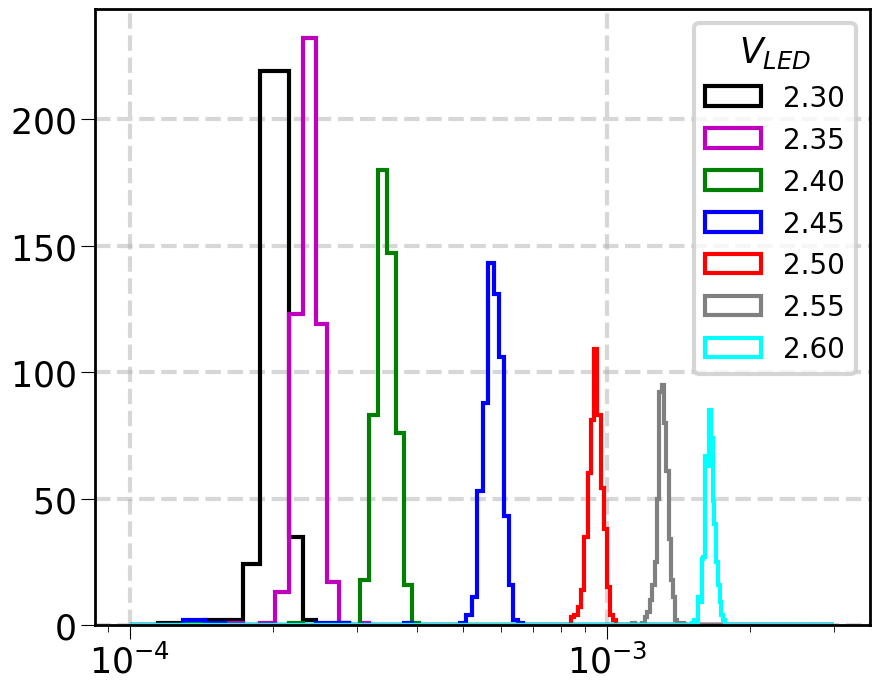

In [112]:
for v in mp2hg.vled.unique():
    data = mp2hg.loc[lambda df: df.vled == v]
    plt.hist(data.preamp_sub, np.linspace(1e-4, 30e-4, 201), histtype="step", label=f"{v/1e3:.2f}")

plt.legend(fontsize=20, title="$V_{{LED}}$")
plt.xscale("log")
plt.grid()